In [1]:
import numpy as np
import pandas as pd
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import plotly.express as px
import plotly.graph_objs as go
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score

import umap

2024-09-17 11:28:39.652484: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2024-09-17 11:28:39.652521: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


## Data load

In [2]:
# Load data files
nuclei = pd.read_csv('/app/data/cellprofiler_segmentation/watershed_nuclei.txt', sep='\t', index_col = 1)
cytoplasm = pd.read_csv('/app/data/cellprofiler_segmentation/filtered_segmented_cytoplasm.txt', sep='\t', index_col = 1)

In [3]:
# Merge files
nuclei_cytoplasm = pd.merge(nuclei, cytoplasm, left_on = 'Children_filtered_segmented_cytoplasm_Count', right_on = 'ObjectNumber', suffixes = ('_nuclei', '_cytoplasm'))

# Delete coordinates features
columns_to_drop = [col for col in nuclei_cytoplasm.columns if 'X' in col or 'Y' in col or 'Z' in col]
nuclei_cytoplasm = nuclei_cytoplasm.drop(columns=columns_to_drop)

# Delete IDs and other useless stuff
nuclei_cytoplasm = nuclei_cytoplasm.drop(columns=['Children_filtered_segmented_cytoplasm_Count', 'Parent_segmented_cytoplasm', 'Parent_watershed_nuclei', 'ImageNumber_nuclei', 'Number_Object_Number_nuclei', 'ImageNumber_cytoplasm', 'Number_Object_Number_cytoplasm'])

In [4]:
display(nuclei_cytoplasm)

,AreaShape_BoundingBoxVolume_nuclei,AreaShape_EquivalentDiameter_nuclei,AreaShape_EulerNumber_nuclei,AreaShape_Extent_nuclei,AreaShape_MajorAxisLength_nuclei,AreaShape_MinorAxisLength_nuclei,AreaShape_SurfaceArea_nuclei,AreaShape_Volume_nuclei,AreaShape_BoundingBoxVolume_cytoplasm,AreaShape_EquivalentDiameter_cytoplasm,AreaShape_EulerNumber_cytoplasm,AreaShape_Extent_cytoplasm,AreaShape_MajorAxisLength_cytoplasm,AreaShape_MinorAxisLength_cytoplasm,AreaShape_SurfaceArea_cytoplasm,AreaShape_Volume_cytoplasm
0,1792,9.834303,0,0.277902,28.236047,14.801025,378.552704,498,17550,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854
1,14620,24.270780,0,0.512038,49.625393,26.442739,1480.238281,7486,17550,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854
2,3360,9.514646,1,0.134226,24.445469,13.891595,651.103027,451,17550,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854
3,1188,9.912667,1,0.429293,24.723139,15.361054,390.437103,510,17550,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854
4,12920,23.409506,1,0.519892,46.726937,32.016631,1963.811646,6717,17550,26.599368,1,0.561481,56.816560,38.431274,1874.890869,9854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,798,8.710154,-1,0.433584,27.627781,17.376481,380.693848,346,5220,18.231559,1,0.607854,32.457302,19.753127,578.871826,3173
378,50840,34.232173,1,0.413139,88.398997,49.418769,4635.945312,21004,13600,23.387412,0,0.492500,49.696019,27.783340,1424.442871,6698
379,25370,24.352638,-5,0.298069,57.294631,34.660827,2514.415039,7562,8820,18.738301,1,0.390590,38.710415,20.184015,722.996399,3445
380,24360,25.646030,1,0.362562,63.824693,32.020387,2357.136230,8832,8820,18.738301,1,0.390590,38.710415,20.184015,722.996399,3445


## Standarization

In [5]:
# Standardize the data
scaler = StandardScaler()
nuclei_cytoplasm_std = scaler.fit_transform(nuclei_cytoplasm)

## PCA

In [6]:
# Perform PCA
pca = PCA()
pca.fit(nuclei_cytoplasm_std)

PCA()

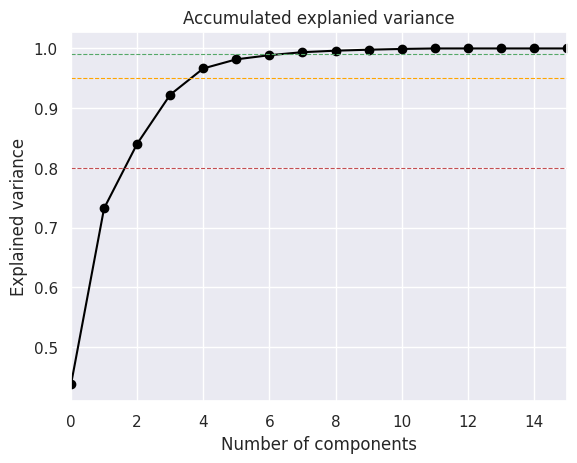

In [7]:
# Explained variance
pca.explained_variance_ratio_

plt.figure()

plt.plot(pca.explained_variance_ratio_.cumsum(), marker = 'o', color='black')
plt.xlabel('Number of components')
plt.ylabel('Explained variance')
plt.axhline(y=0.99, color='g', linestyle='--', linewidth=0.8, label='y = 0.99')
plt.axhline(y=0.95, color='orange', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.axhline(y=0.8, color='r', linestyle='--', linewidth=0.8, label='y = 0.8')
plt.xlim(0, 15)

plt.title('Accumulated explanied variance')

plt.savefig('/app/html/1-explained_variance.svg', format='svg')

plt.show()

In [8]:
pca = PCA(n_components = 2)

In [9]:
pca.fit(nuclei_cytoplasm_std)

PCA(n_components=2)

In [10]:
pca_result = pca.transform(nuclei_cytoplasm_std)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])

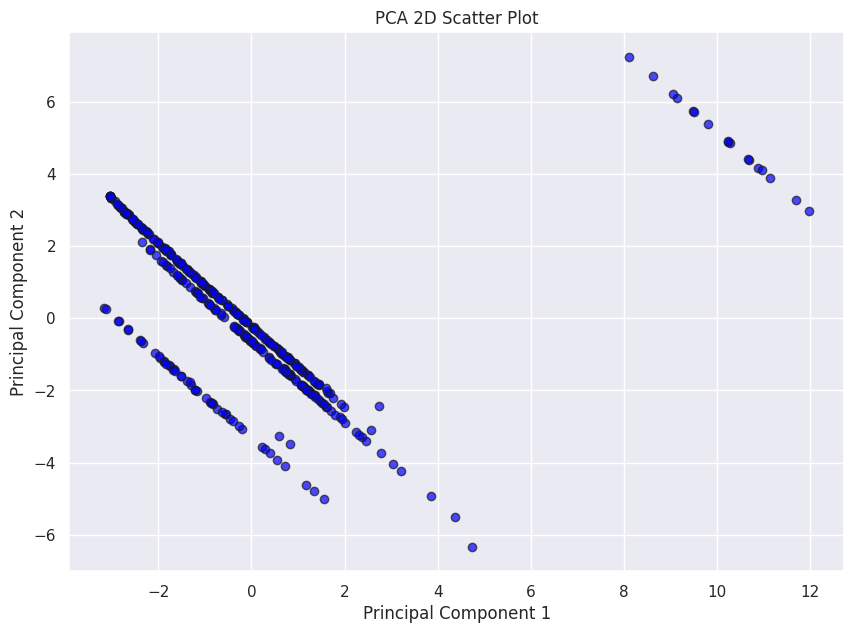

In [11]:
# 2D plot
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c='blue', edgecolor='k', alpha=0.7)
plt.title('PCA 2D Scatter Plot')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.savefig('/app/html/2-pca.svg', format='svg')

plt.show()

### K-Means

In [12]:
scores_pca = pca.transform(nuclei_cytoplasm_std)
scores_pca

array([[-1.60881017e+00,  1.62172759e+00],
       [ 5.45554012e-01, -8.09996084e-01],
       [-1.58065386e+00,  1.57644539e+00],
       [-1.73834767e+00,  1.77099000e+00],
       [ 6.14881521e-01, -9.20609010e-01],
       [-2.83088727e+00,  3.09892268e+00],
       [ 5.68938612e-01, -8.58823353e-01],
       [-1.20049087e+00,  1.14899470e+00],
       [-1.85916801e+00,  1.92209068e+00],
       [ 1.21311059e+00, -1.58160534e+00],
       [-1.86698400e+00,  1.94159464e+00],
       [ 1.21525219e+00, -1.58071053e+00],
       [-1.47535339e+00,  1.46235863e+00],
       [-6.30101203e-01,  5.11330009e-01],
       [-3.54223205e-01,  1.84573597e-01],
       [-2.63997650e+00,  2.86356470e+00],
       [-7.20585134e-01,  5.87621693e-01],
       [-3.04723207e+00,  3.39223669e+00],
       [-1.59054673e+00,  1.58765744e+00],
       [-2.86096209e+00,  3.13705222e+00],
       [-2.54512678e+00,  2.73315647e+00],
       [ 6.02543994e-01, -9.02212963e-01],
       [ 6.60240174e-01, -9.80111756e-01],
       [-8.

In [13]:
wcss = []
for i in range (1,21):
    kmeans_pca = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans_pca.fit(scores_pca)
    wcss.append(kmeans_pca.inertia_)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explic

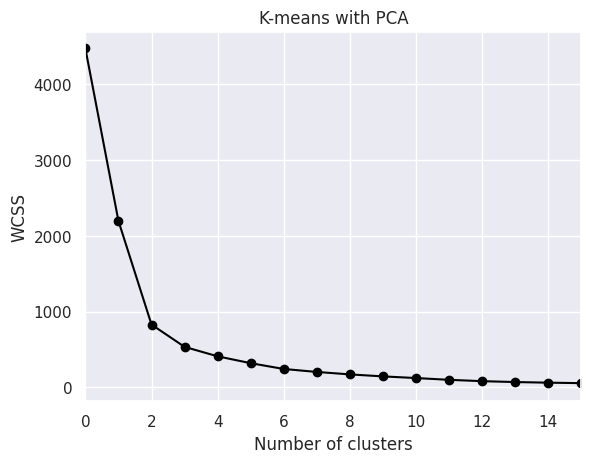

In [14]:
plt.figure()

plt.plot(wcss, marker = 'o', color='black')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('K-means with PCA')

plt.xlim(0, 15)

plt.savefig('/app/html/3-kmeans_pca.svg', format='svg')

plt.show()

In [15]:
kmeans_pca = KMeans(n_clusters = 2, init = 'k-means++', random_state = 42)

In [16]:
kmeans_pca.fit(scores_pca)

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=2, random_state=42)

In [17]:
df_segm_pca_kmeans = pd.concat([nuclei_cytoplasm.reset_index(drop = True), pd.DataFrame(scores_pca)], axis = 1)
df_segm_pca_kmeans.columns.values[-2: ] = ['C1', 'C2']
df_segm_pca_kmeans['Segment K-means PCA'] = kmeans_pca.labels_

In [18]:
df_segm_pca_kmeans['Segment'] = df_segm_pca_kmeans['Segment K-means PCA'].map({
    0:'Primero',
    1:'Segundo'})

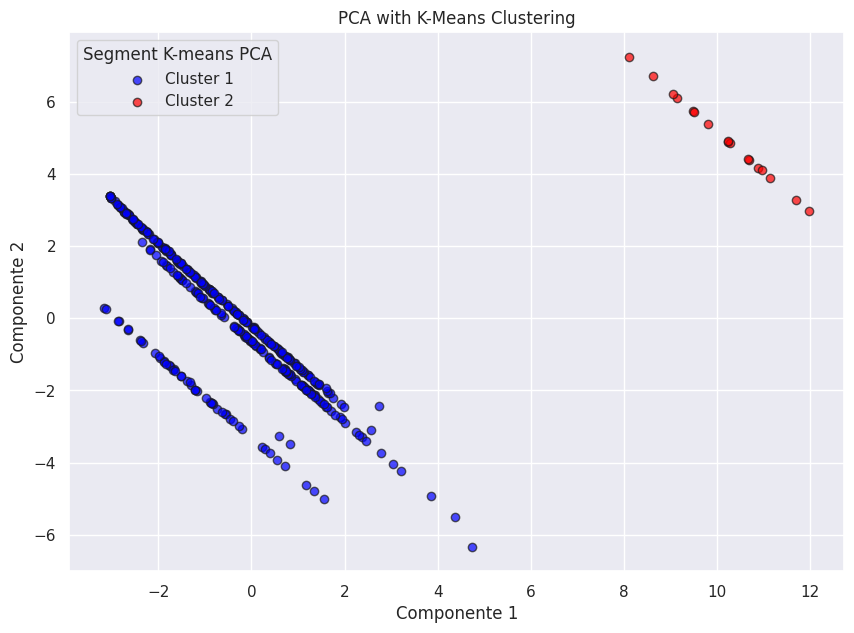

In [19]:
# Suponiendo que 'df_segm_pca_kmeans' es tu DataFrame con las componentes PCA y los clusters
df_plotly = df_segm_pca_kmeans.copy()
df_plotly['Segment K-means PCA'] = df_plotly['Segment K-means PCA'].map({
    0: 'Cluster 1',
    1: 'Cluster 2'
})

# Crear el gráfico 2D
plt.figure(figsize=(10, 7))
for cluster, color in {'Cluster 1': 'blue', 'Cluster 2': 'red'}.items():
    subset = df_plotly[df_plotly['Segment K-means PCA'] == cluster]
    plt.scatter(subset['C1'], subset['C2'], label=cluster, color=color, edgecolor='k', alpha=0.7)

plt.title('PCA with K-Means Clustering')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.legend(title='Segment K-means PCA')
plt.grid(True)

# Guardar el gráfico en un archivo SVG
plt.savefig('/app/html/4-pca_kmeans.svg', format='svg')

# Mostrar el gráfico (opcional)
plt.show()

df_plotly = df_segm_pca_kmeans.copy()
df_plotly['Segment K-means PCA'] = df_plotly['Segment K-means PCA'].map({
    0: 'Cluster 1',
    1: 'Cluster 2'
})
fig = px.scatter_3d(df_plotly, x='C1', y='C2', color='Segment K-means PCA',
                    labels={'C1': 'Componente 1', 'C2': 'Componente 2'},
                    title='PCA with K-Means Clustering')

fig.write_html('/app/html/4-pca_kmeans.html')

## UMap

In [20]:
n_neighbors = 5
min_dist = 1
n_components = 2
local_connectivity = 0.1
spread = 1
random_state = 42

/usr/local/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


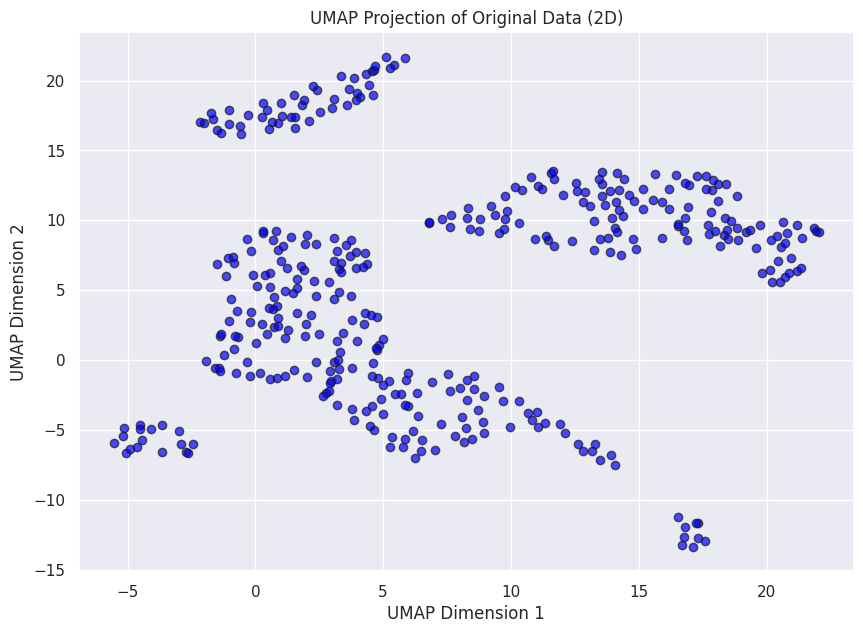

In [21]:
umap_model_3d = umap.UMAP(n_neighbors=5, min_dist=min_dist, metric='euclidean', 
                         n_components=n_components, local_connectivity=local_connectivity, 
                         spread=spread, random_state=random_state)
umap_result_3d = umap_model_3d.fit_transform(nuclei_cytoplasm_std)
df_umap_3d = pd.DataFrame(umap_result_3d, columns=['UMAP1', 'UMAP2'])

plt.figure(figsize=(10, 7))
plt.scatter(df_umap_3d['UMAP1'], df_umap_3d['UMAP2'], c='blue', edgecolor='k', alpha=0.7)
plt.title('UMAP Projection of Original Data (2D)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.grid(True)

plt.savefig('/app/html/5-umap_2d.svg', format='svg')

plt.show()

umap_model_3d = umap.UMAP(n_neighbors=5, min_dist=min_dist, metric='euclidean', n_components=n_components, local_connectivity=local_connectivity, spread=spread, random_state=random_state)
umap_result_3d = umap_model_3d.fit_transform(nuclei_cytoplasm_std)
df_umap_3d = pd.DataFrame(umap_result_3d, columns=['UMAP1', 'UMAP2'])

fig_3d = px.scatter_3d(df_umap_3d, x='UMAP1', y='UMAP2',
                      labels={'UMAP1': 'UMAP Dimension 1', 'UMAP2': 'UMAP Dimension 2'},
                      title='UMAP Projection of Original Data (3D)')

fig_3d.write_html('/app/html/5-umap_3d.html')

### K-means

/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explic

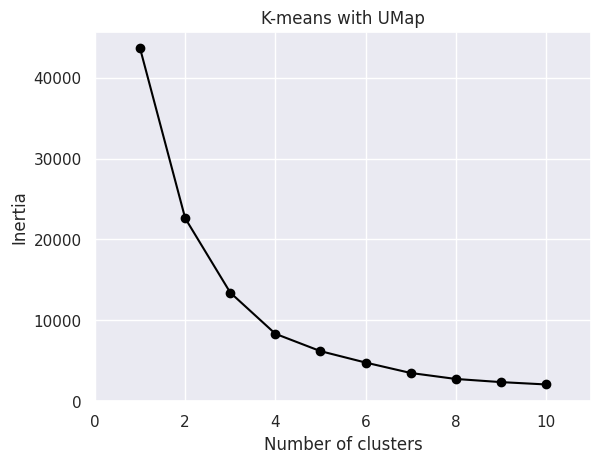

In [22]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(umap_result_3d)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker = 'o', color='black')

plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('K-means with UMap')

plt.xlim(0, 11)

plt.savefig('/app/html/6-kmeans_umap.svg', format='svg')

plt.show()

/usr/local/lib/python3.8/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/usr/local/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


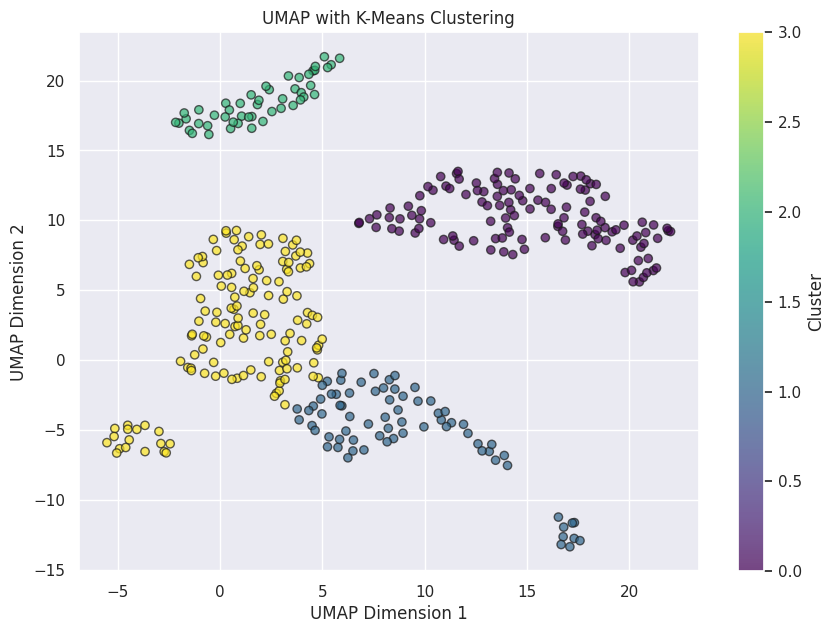

In [23]:
umap_model_3d = umap.UMAP(n_neighbors=5, min_dist=min_dist, metric='euclidean', 
                         n_components=n_components, local_connectivity=local_connectivity, 
                         spread=spread, random_state=random_state)
umap_result_3d = umap_model_3d.fit_transform(nuclei_cytoplasm_std)

kmeans = KMeans(n_clusters=4)
clusters = kmeans.fit_predict(umap_result_3d)

df_umap_3d = pd.DataFrame(umap_result_3d, columns=['UMAP1', 'UMAP2'])
df_umap_3d['Cluster'] = clusters

plt.figure(figsize=(10, 7))
scatter = plt.scatter(df_umap_3d['UMAP1'], df_umap_3d['UMAP2'], c=df_umap_3d['Cluster'], cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('UMAP with K-Means Clustering')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)

plt.savefig('/app/html/7-umap_kmeans.svg', format='svg')

plt.show()

### Heatmap

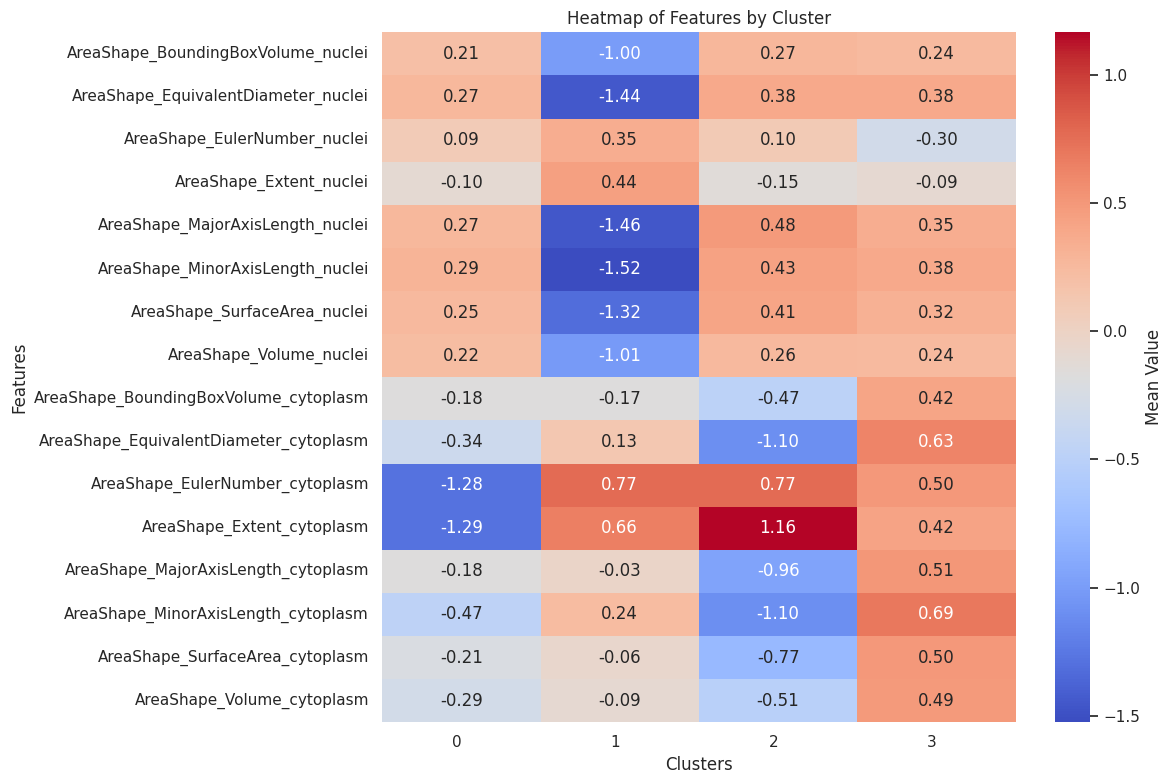

In [24]:
df_std_with_clusters = pd.concat([pd.DataFrame(nuclei_cytoplasm_std, columns=nuclei_cytoplasm.columns), df_umap_3d['Cluster']], axis=1)

heatmap_data = df_std_with_clusters.groupby('Cluster').mean()

heatmap_data_transposed = heatmap_data.T

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data_transposed, cmap='coolwarm', annot=True, fmt=".2f", cbar_kws={'label': 'Mean Value'})
plt.title('Heatmap of Features by Cluster')
plt.xlabel('Clusters')
plt.ylabel('Features')
plt.xticks(ha='right')
plt.tight_layout()

plt.savefig('/app/html/8-heatmap_features_by_cluster.svg', format='svg')

plt.show()